<a href="https://colab.research.google.com/github/veapasichnyk/HomeWorksDataLovesAcademy/blob/main/HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [3]:
df = pd.read_csv("marketing_campaign.csv",sep='\t')

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())


(2240, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 n

**Попередній огляд**

- Розмір: (2240 × 29)

- Пропуски: тільки в Income (24 значення відсутні).

Типи даних:

- Числові (25 колонок)

- Категоріальні (Education, Marital_Status, Dt_Customer)

Також у нас є дві технічні фічі - Z_CostContact і Z_Revenue константні та ID - можна прибрати, бо вони не дають жодної інформації для алгоритму.

In [6]:
df = df.drop(columns=["Z_CostContact", "Z_Revenue", "ID"])

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

**Чому саме медіана?**

- Вона не спотворюється через дуже великі/малі доходи.

- Дає реалістичне значення для "типового" клієнта.

- Дозволяє зберегти всі 2240 рядків для подальшої кластеризації.

In [8]:
print(df.isnull().sum())

Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
dtype: int64


**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

**Пояснення**

У задачі кластеризації клієнтів важливо підготувати дані так, щоб усі ознаки були числовими та відображали корисну інформацію про клієнта.

One-Hot Encoding робить категорії придатними для обчислення відстаней у багатовимірному просторі.

Дата приєднання клієнта сама по собі не підходить для кластеризації, але з неї можна витягнути корисні ознаки `Customer_For` - скільки днів клієнт уже з компанією ("вік клієнта" в компанії).

Такі ознаки роблять кластери інтерпретованими: можна буде зрозуміти, що, наприклад, "довгострокові клієнти з високим доходом і частими покупками" утворюють окрему групу.

In [9]:
# Обробка дат
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
df["Customer_For"] = (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days
df["Year_Customer"] = df["Dt_Customer"].dt.year
df["Month_Customer"] = df["Dt_Customer"].dt.month
df = df.drop(columns=["Dt_Customer"])  # саму дату прибираємо

# One-Hot Encoding для категоріальних
df = pd.get_dummies(df, columns=["Education", "Marital_Status"], drop_first=True)

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [10]:
# X = дані для кластеризації
X = df.copy()

In [11]:
# KMeans на 3 кластери
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X)

labels = kmeans.predict(X)
print(labels)

[0 0 1 ... 0 1 0]


In [12]:
# Обчислюємо силует
silhouette = silhouette_score(X, labels)

print(f"Silhouette Score for 3 clusters: {silhouette:.4f}")

Silhouette Score for 3 clusters: 0.5379


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [13]:
# Додаємо кластери до оригінального датафрейму
df["Cluster"] = labels

In [14]:
# Створимо датафрейм з кількома ключовими ознаками та кластерами
viz_df = pd.DataFrame({
    "Income": df["Income"],
    "MntWines": df["MntWines"],
    "NumWebPurchases": df["NumWebPurchases"],
    "Cluster": df["Cluster"]
})

In [15]:
# 3D візуалізація
fig = px.scatter_3d(
    viz_df,
    x="Income",
    y="MntWines",
    z="NumWebPurchases",
    color="Cluster",
    opacity=0.7
)
fig.update_traces(marker=dict(size=4))
fig.show()

**Спостереження**

Перекриття між кластерами означає, що дані не ідеально розділяються, але основні патерни видно.

1. Кластер 2 (жовті точки):

- Низькі доходи (часто <30k).

- Дуже мало покупок вина і веб-покупок.

Це, ймовірно, клієнти з низькою активністю.

2. Кластер 0 (сині точки):

- Доходи середнього рівня (30k – 60k).

- Витрати на вино теж середні, але вище, ніж у Кластера 0.

- Кількість веб-покупок помірна.

Це, скоріше, "середні" клієнти, які купують регулярно, але не витрачають занадто багато.

3. Кластер 1 (рожеві точки):

- Вищі доходи (>60k, є навіть >100k).

- Більші витрати на вино.

- Більше веб-покупок.

Це потенційно преміум-клієнти - варто робити персоналізовані пропозиції, елітні товари.

**Завдання 6**. Масштабуйте дані і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [16]:
df = df.drop(columns=["Cluster"])

In [17]:
# Масштабування всіх числових колонок
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print("Форма після обробки:", df_scaled.shape)
print(df_scaled.head())

Форма після обробки: (2240, 37)
   Year_Birth    Income   Kidhome  Teenhome   Recency  MntWines  MntFruits  \
0   -0.985345  0.235696 -0.825218 -0.929894  0.307039  0.983781   1.551577   
1   -1.235733 -0.235454  1.032559  0.906934 -0.383664 -0.870479  -0.636301   
2   -0.317643  0.773999 -0.825218 -0.929894 -0.798086  0.362723   0.570804   
3    1.268149 -1.022355  1.032559 -0.929894 -0.798086 -0.870479  -0.560857   
4    1.017761  0.241888  1.032559 -0.929894  1.550305 -0.389085   0.419916   

   MntMeatProducts  MntFishProducts  MntSweetProducts  ...  \
0         1.679702         2.462147          1.476500  ...   
1        -0.713225        -0.650449         -0.631503  ...   
2        -0.177032         1.345274         -0.146905  ...   
3        -0.651187        -0.503974         -0.583043  ...   
4        -0.216914         0.155164         -0.001525  ...   

   Education_Graduation  Education_Master  Education_PhD  \
0              0.993769         -0.444816      -0.526385   
1     

In [18]:
X_scaled = df_scaled.copy()

In [19]:
# KMeans на 3 кластери
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X_scaled)

labels = kmeans.predict(X_scaled)
print(labels)

[1 0 2 ... 2 2 0]


In [20]:
# Обчислюємо силует
silhouette = silhouette_score(X_scaled, labels)

print(f"Silhouette Score for 3 clusters: {silhouette:.4f}")

Silhouette Score for 3 clusters: 0.1116


**Спостереження**

До масштабування Silhouette Score = 0.5379 - доволі хороший результат, кластери були чіткіші.

Після масштабування (StandardScaler) Silhouette Score = 0.1116 - якість кластеризації сильно погіршилась, кластери почали перекриватися.

1. Вплив масштабу ознак

Без масштабування такі фічі як `Income`, `MntWines` або інші витрати мають великі значення, і вони домінували у відстанях між точками.

Кластери формувалися здебільшого за цими кількома "великими" ознаками - вийшов непоганий поділ.

2. Після масштабування

Усі ознаки отримали однакову вагу.

У результаті дрібні показники (наприклад, `NumWebPurchases`, `Kidhome`, `Teenhome`) почали впливати на відстані так само сильно, як і `Income`.

Це "розмило" межі між кластерами - модель втратила фокус на головних драйверах (дохід + витрати).

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

**Спостереження**

`Income`: максимум 666,666 при медіані ~51k і 75% квартилі ~68k - це явний outlier.

`MntWines`: максимум 1493, при медіані ~173 і 75% квартилі ~504 - теж викиди.

`MntMeatProducts`: максимум 1725 при медіані ~67 → явні outliers.

Інші витратні колонки (MntFruits, MntFishProducts, MntSweetProducts, MntGoldProds) теж мають максимум, що суттєво відрізняється від 75% квартиля, але не так екстремально.

Щоб вирішити - видаляти чи обробляти викиди, треба порахувати яку частку даних вони займають.

In [21]:
def outlier_ratio(series, lower=1, upper=99):
    lower_val = np.percentile(series, lower)
    upper_val = np.percentile(series, upper)
    outliers = ((series < lower_val) | (series > upper_val)).sum()
    ratio = outliers / len(series) * 100
    return outliers, ratio

# Для доходів
outliers_income, ratio_income = outlier_ratio(df["Income"])
print(f"Income: {outliers_income} рядків ({ratio_income:.2f}%)")

# Для витрат на вино
outliers_wine, ratio_wine = outlier_ratio(df["MntWines"])
print(f"MntWines: {outliers_wine} рядків ({ratio_wine:.2f}%)")

# Для витрат на м'ясо
outliers_wine, ratio_wine = outlier_ratio(df["MntMeatProducts"])
print(f"MntMeatProducts: {outliers_wine} рядків ({ratio_wine:.2f}%)")

Income: 46 рядків (2.05%)
MntWines: 35 рядків (1.56%)
MntMeatProducts: 37 рядків (1.65%)


In [22]:
def cap_outliers(series, lower=1, upper=99):
    lower_val = np.percentile(series, lower)
    upper_val = np.percentile(series, upper)
    return np.clip(series, lower_val, upper_val)

# Застосуємо до ключових колонок
df["Income"] = cap_outliers(df["Income"])
df["MntWines"] = cap_outliers(df["MntWines"])
df["MntMeatProducts"] = cap_outliers(df["MntMeatProducts"])

# Перевіримо після обробки
print(df[["Income","MntWines","MntMeatProducts"]].describe())

             Income     MntWines  MntMeatProducts
count   2240.000000  2240.000000      2240.000000
mean   51767.195893   302.909821       165.075446
std    20614.112834   333.316827       216.547373
min     7705.920000     1.000000         2.000000
25%    35538.750000    23.750000        16.000000
50%    51381.500000   173.500000        67.000000
75%    68289.750000   504.250000       232.000000
max    94437.680000  1285.000000       915.000000


**Спостереження**

Екстремальні "аномалії" обрізалися: тепер значення верхнього діапазону більш адекватні.

Середні значення (mean/median) практично не змінилися - дані зберегли реалістичний розподіл.

При цьому ми не втратили жодного клієнта, лише обмежили вплив найбільш нетипових.

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

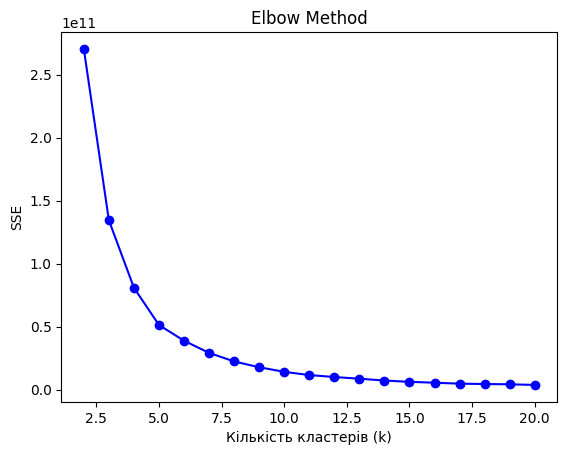

In [23]:
#Elbow method для не масштабованих даних
sse = []
K = range(2, 21)  # перевіримо від 2 до 20 кластерів
X = df.copy()

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.plot(K, sse, 'o-', color='blue')
plt.xlabel("Кількість кластерів (k)")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

In [25]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

df["Cluster"] = labels

silhouette = silhouette_score(X, labels)
print(f"Silhouette Score for {optimal_k} clusters: {silhouette:.4f}")

Silhouette Score for 5 clusters: 0.5420


In [26]:
viz_df = pd.DataFrame({
    "Income": df["Income"],
    "MntWines": df["MntWines"],
    "NumWebPurchases": df["NumWebPurchases"],
    "Cluster": df["Cluster"]
})

fig = px.scatter_3d(
    viz_df,
    x="Income", y="MntWines", z="NumWebPurchases",
    color="Cluster", opacity=0.7
)
fig.show()

**Спостереження**

При оптимальній кількості кластерів 5 ми бачимо гарне відокремлення їх між собою:

1. Кластер з низьким доходом і низькими витратами.

2. Кластер з середнім доходом, але малою кількістю покупок.

3. Кластер з високим доходом і високими витратами (особливо на вино).

4. Кластер з середнім доходом і активними онлайн-покупками.

5. Кластер з помірним доходом і значними витратами на продукти, але не онлайн

Також Silhouette Score = 0.5420 - означає, що кластери достатньо чіткі та відділені.

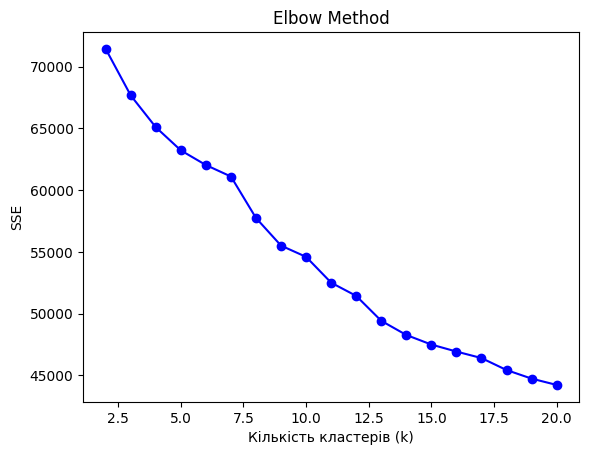

In [27]:
#Elbow method для масштабованих даних
sse = []
K = range(2, 21)  # перевіримо від 2 до 20 кластерів

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.plot(K, sse, 'o-', color='blue')
plt.xlabel("Кількість кластерів (k)")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

Бачимо, що для масштабованих ознак оптимальна кількість кластерів десь 14 - 15.

In [30]:
optimal_k = 15
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

df_scaled["Cluster"] = labels

silhouette = silhouette_score(X, labels)
print(f"Silhouette Score for {optimal_k} clusters: {silhouette:.4f}")

Silhouette Score for 15 clusters: -0.3205


In [31]:
viz_df = pd.DataFrame({
    "Income": df_scaled["Income"],
    "MntWines": df_scaled["MntWines"],
    "NumWebPurchases": df_scaled["NumWebPurchases"],
    "Cluster": df_scaled["Cluster"]
})

fig = px.scatter_3d(
    viz_df,
    x="Income", y="MntWines", z="NumWebPurchases",
    color="Cluster", opacity=0.7
)
fig.show()

Очікувано, що при Silhouette = -0.3205 (від’ємне значення - точки частіше лежать ближче до центроїда іншого кластера, ніж свого), k=15 та масштабуванні ознак - межі кластерів перетинаються, клієнти "плутаються" між сегментами і кластеризація є невдалою.

Масштабування "збиває" структуру даних, бо всі ознаки починають мати однакову вагу, навіть ті, які слабко впливають на портрет клієнта.

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

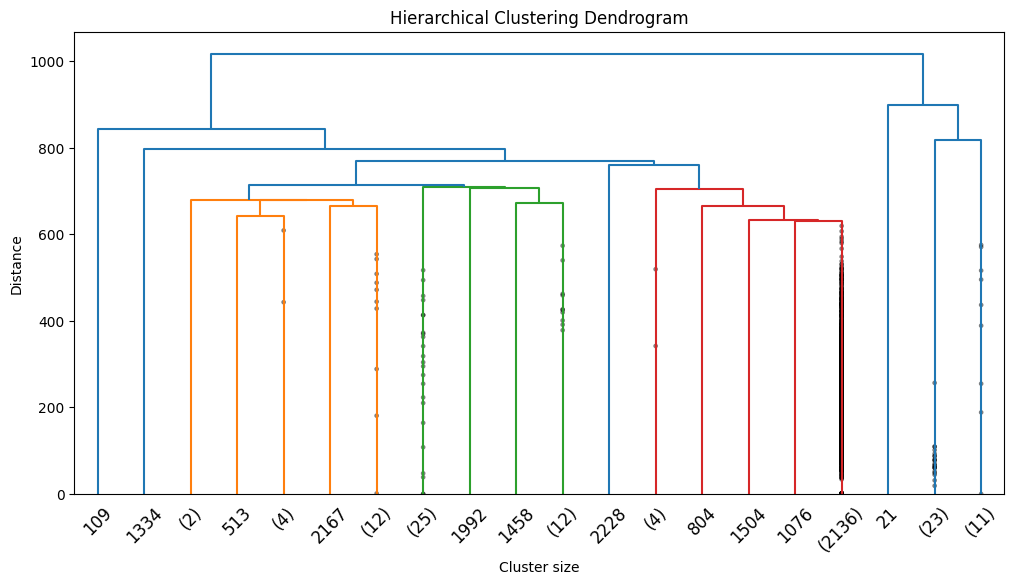

In [34]:
# Використовуємо single linkage
Z = linkage(X, method="single")

# Побудова дендрограми з обрізкою
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45., leaf_font_size=12., show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.show()

In [35]:
# 2 кластери
labels_2 = fcluster(Z, 2, criterion="maxclust")
sil_2 = silhouette_score(X, labels_2)
print(f"Silhouette Score for 2 clusters: {sil_2:.4f}")

# 3 кластери
labels_3 = fcluster(Z, 3, criterion="maxclust")
sil_3 = silhouette_score(X, labels_3)
print(f"Silhouette Score for 3 clusters: {sil_3:.4f}")

Silhouette Score for 2 clusters: 0.3692
Silhouette Score for 3 clusters: 0.3540


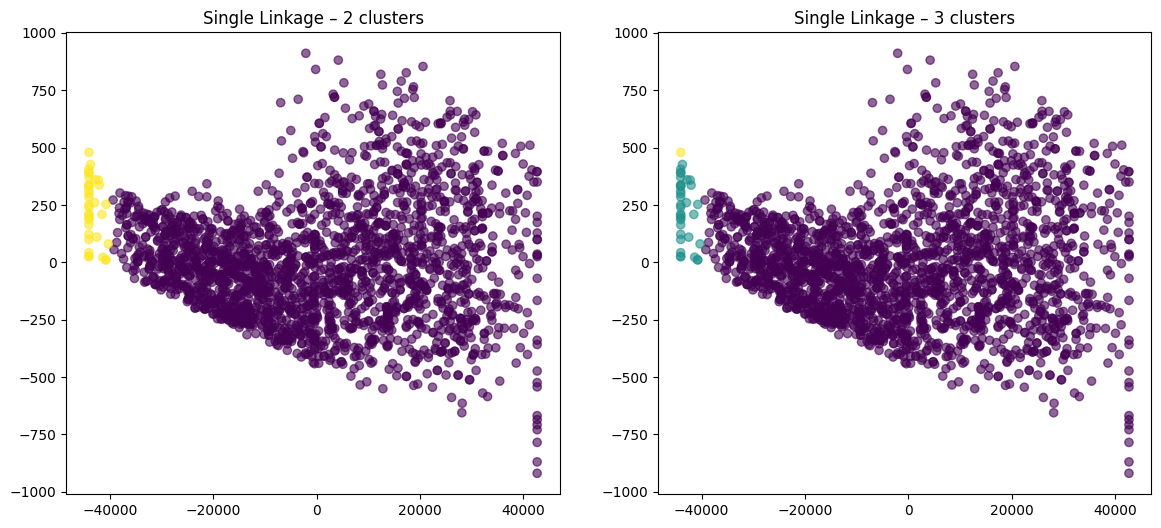

In [37]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# 2 кластери
axes[0].scatter(reduced[:,0], reduced[:,1], c=labels_2, cmap="viridis", alpha=0.6)
axes[0].set_title("Single Linkage – 2 clusters")

# 3 кластери
axes[1].scatter(reduced[:,0], reduced[:,1], c=labels_3, cmap="viridis", alpha=0.6)
axes[1].set_title("Single Linkage – 3 clusters")

plt.show()

**Спостереження**

2 кластери - Silhouette = 0.3692

3 кластери - Silhouette = 0.3540

Обидві метрики позитивні, але не високі.

Кластеризація виглядає невдалою: більшість точок потрапляє в один кластер, сегментація малоінформативна.

Поки що для цієї задачі single linkage не оптимальний. Значно краще працює KMeans (де ми отримали Silhouette ≈ 0.54 для k=5).

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [46]:
# Ward linkage
ward = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels = ward.fit_predict(X)


In [47]:
# Silhouette Score
sil = silhouette_score(X, labels)
print(f"Silhouette Score (Ward linkage, 5 clusters): {sil:.4f}")

Silhouette Score (Ward linkage, 5 clusters): 0.5173


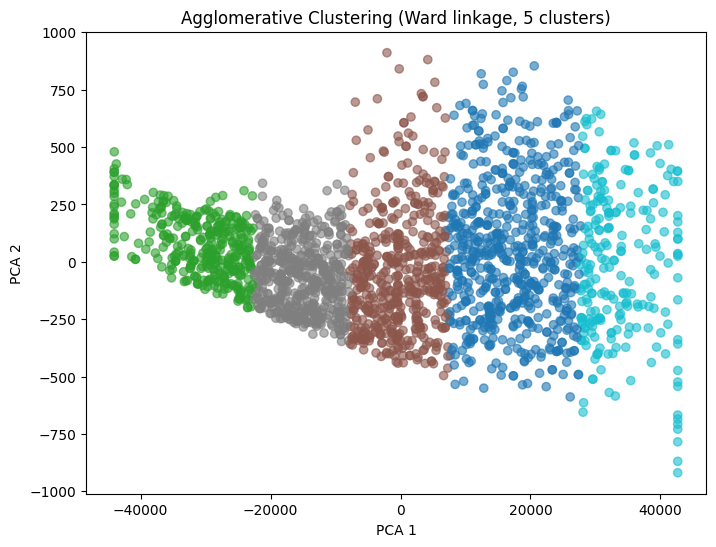

In [49]:
# PCA для візуалізації
pca = PCA(n_components=2)
reduced = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap="tab10", alpha=0.6)
plt.title("Agglomerative Clustering (Ward linkage, 5 clusters)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

**Спостереження**

Ward linkage добре працює для цього датасету:

- кластери компактні й збалансовані,

- результат співставний з KMeans,

- метрика Silhouette підтверджує якість (>0.5).

Цю кластеризацію можна вважати корисною для Customer Personality Analysis.